In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pygeohash as pgh
import pandas as pd

# Geohashing Results for Ice Climbs

1. Create dataset of random coordinates 
2. Create hash of each
3. Input lat, lng find closest one

Could web scrape Ice Climbing Atlas but out of scope

### Create Dataset

In [146]:
canmore_lat, canmore_lon= 51.0883666, -115.3479101
canmore_lat

51.0883666

In [164]:
def generate_random_coords(centre, n=100):
    # at 51 degrees north, 1 degree is roughly 70km
    # Generate points within 7km: 0.1 degrees   
    rng = np.random.default_rng()
    return rng.uniform(centre - 0.05, centre + 0.05, size=n)


lats = generate_random_coords(canmore_lat)
lons = generate_random_coords(canmore_lon)

In [149]:
len(lats), len(lons)

(100, 100)

### Hash

https://www.pubnub.com/guides/what-is-geohashing/


- Max length is 12 characters
- Coordinates are encoded using Base-32 (0-9, alphabet A, I, L, O)
- First character represents a 5,000km box
- Last character represents a 4.77m box
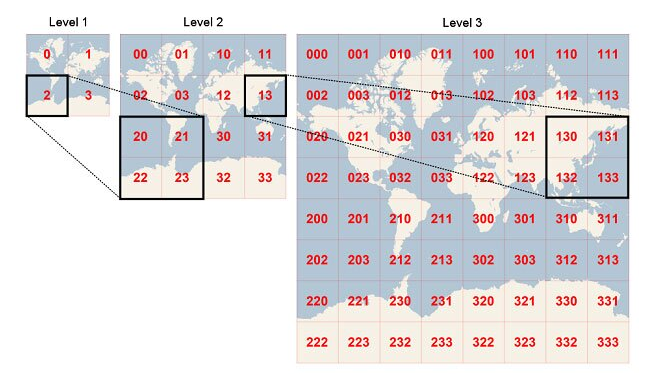

In [150]:

# Encode coordinates to geohash
geohash = pgh.encode(latitude=42.6, longitude=-5.6)
geohash

'ezs42e44yx96'

In [151]:
coords_df = pd.DataFrame({"lat": lats, "lon": lons})
coords_df["hash"] = coords_df.apply(
    lambda row: pgh.encode(latitude=row["lat"], longitude=row["lon"]), axis=1
)
coords_df

,lat,lon,hash
0,51.119539,-115.358467,c3jfyfn8busv
1,51.107171,-115.360156,c3jfwzv2ce1r
2,51.043035,-115.356812,c3jfqupeprqc
3,51.105515,-115.329517,c3jfxx7x5qrw
4,51.102219,-115.360101,c3jfwyvk4b42
...,...,...,...
95,51.046534,-115.389337,c3jfqk8p9edq
96,51.057642,-115.390880,c3jfqnybmd7u
97,51.127961,-115.347130,c3jfz5wccnf6
98,51.054909,-115.351120,c3jfrn7bkhfu


### Search

In [152]:
search_hash = coords_df.iloc[50].hash
search_hash

'c3n4bhg8x0js'

The first character is a 5,000km square. The next character is 5,000/4 and so on.

Each successive character represents the previous one divided by 4. The search precision can be learned from the map

In [154]:
search_hash = "c3jfw7wk7pte"

char_precision = {i: round(5_000_000 / (4**i), 1) for i in range(len(search_hash) - 1)}
char_precision

{0: 5000000.0,
 1: 1250000.0,
 2: 312500.0,
 3: 78125.0,
 4: 19531.2,
 5: 4882.8,
 6: 1220.7,
 7: 305.2,
 8: 76.3,
 9: 19.1,
 10: 4.8}

The string index can be used to search for neighbours. To search for points within 5km index 5 will do (4.8km will do)

In [155]:
search_hash[:5]

'c3jfw'

In [156]:
coords_df[coords_df.hash.str.startswith(search_hash[:5])]

,lat,lon,hash
1,51.107171,-115.360156,c3jfwzv2ce1r
4,51.102219,-115.360101,c3jfwyvk4b42
7,51.093728,-115.368312,c3jfwtr6e3pq
13,51.080289,-115.391032,c3jfw4yu6049
25,51.098244,-115.368544,c3jfwwphy543
31,51.068120,-115.383518,c3jfw2sm35kz
41,51.073762,-115.392398,c3jfw1ty4pr2
42,51.093665,-115.363323,c3jfwv6fptrv
49,51.094712,-115.395440,c3jfwje872e7
53,51.066572,-115.396434,c3jfw06uk5n3


### Benchmark

Compare Haversine calculation: O(n) vs Geohashing O(1)

In [157]:
points = list(zip(coords_df["lat"], coords_df["lon"]))
points[:5]

[(51.11953859094256, -115.35846654778281),
 (51.10717121534749, -115.36015573524075),
 (51.043034569469214, -115.35681168828151),
 (51.10551483564291, -115.32951653846153),
 (51.10221862814639, -115.3601008263639)]

In [158]:
char_precision = np.asarray([round(5_000_000 / (4**i), 1) for i in range(len(search_hash) - 1)])
char_precision

array([5.00000e+06, 1.25000e+06, 3.12500e+05, 7.81250e+04, 1.95312e+04,
       4.88280e+03, 1.22070e+03, 3.05200e+02, 7.63000e+01, 1.91000e+01,
       4.80000e+00])

In [159]:
hashed_p = np.asarray([pgh.encode(latitude=point[0], longitude=point[1]) for point in points])
hashed_p[:5]

array(['c3jfyfn8busv', 'c3jfwzv2ce1r', 'c3jfqupeprqc', 'c3jfxx7x5qrw',
       'c3jfwyvk4b42'], dtype='<U12')

In [161]:
brute_force_search(points, canmore_lat, canmore_lon, 5_000)

[(51.11953859094256, -115.35846654778281),
 (51.10717121534749, -115.36015573524075),
 (51.10551483564291, -115.32951653846153),
 (51.10221862814639, -115.3601008263639),
 (51.12466409835876, -115.31281623899078),
 (51.11050147067132, -115.37142439059258),
 (51.093727838662524, -115.36831222252069),
 (51.10399903937549, -115.33534944357262),
 (51.06065954985731, -115.3366085052285),
 (51.10665848114092, -115.35217598950858),
 (51.068280575102555, -115.34931844664737),
 (51.08775830804625, -115.35130671555424),
 (51.08028920980406, -115.39103169438972),
 (51.06132161604006, -115.33495438048875),
 (51.11340749635638, -115.33494183847222),
 (51.044493411559166, -115.36123712439299),
 (51.12227596359007, -115.34976181910632),
 (51.098957626620475, -115.29994628811792),
 (51.100636107490054, -115.34812977927842),
 (51.077616867557886, -115.35061111342497),
 (51.07896485080429, -115.30735258052991),
 (51.09824390092874, -115.3685444195814),
 (51.0474864917184, -115.34058710455498),
 (51.0454

In [162]:
geohash_search(hashed_p, 51.10245367025937, -115.38772793298875, 5_000)

array(['c3jfwzv2ce1r', 'c3jfwyvk4b42', 'c3jfwtr6e3pq', 'c3jfw4yu6049',
       'c3jfwwphy543', 'c3jfw2sm35kz', 'c3jfw1ty4pr2', 'c3jfwv6fptrv',
       'c3jfwje872e7', 'c3jfw06uk5n3', 'c3jfwb46m3w0', 'c3jfwyv0zxyp',
       'c3jfwfdm5pqg', 'c3jfwbek0duh', 'c3jfwvef096y'], dtype='<U12')

In [163]:
import timeit

radius_m = 5_000

geohash_time = timeit.timeit(
    stmt="geohash_search(hashed_p, canmore_lat, canmore_lon, radius_m)",
    globals=globals(),
    number=100_000,
)

brute_force_time = timeit.timeit(
    stmt="brute_force_search(points, canmore_lat, canmore_lon, radius_m)",
    globals=globals(),
    number=100_000,
)

print(f"Geohash:     {geohash_time:.4f}s ({geohash_time/10_000*1000:.4f}ms per call)")
print(
    f"Brute force: {brute_force_time:.4f}s ({brute_force_time/10_000*1000:.4f}ms per call)"
)
print(f"Speedup: {brute_force_time/geohash_time:.2f}x")

Geohash:     3.2803s (0.3280ms per call)
Brute force: 10.3334s (1.0333ms per call)
Speedup: 3.15x


### Plot

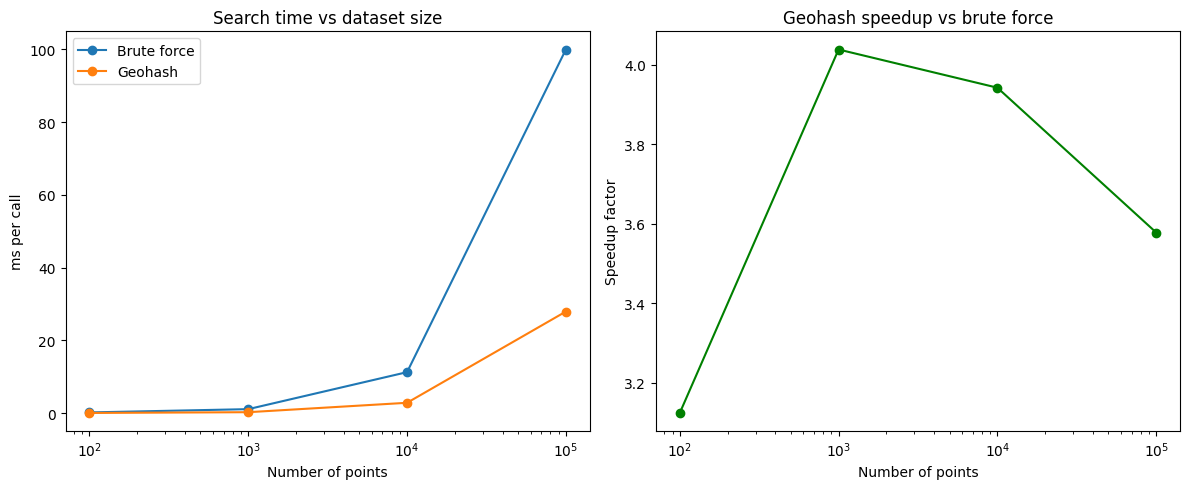

In [ ]:
from dataclasses import dataclass
from math import radians, sin, cos, sqrt, atan2

CHAR_PRECISION = np.asarray([round(5_000_000 / (4**i), 1) for i in range(11)])


@dataclass
class GeoHashBenchmark:
    lat: float
    lon: float
    n: int = 100
    radius: int = 5_000

    def generate_points(self):

        def generate_random_coords(centre):
            # at 51 degrees north, 1 degree is roughly 70km
            # Generate points within 7km: 0.1 degrees
            rng = np.random.default_rng()
            return rng.uniform(centre - 0.05, centre + 0.05, size=self.n)

        lats = generate_random_coords(self.lat)
        lons = generate_random_coords(self.lon)

        self.points = list(zip(lats, lons))

    def generate_hash(self):
        self.hashed_points = np.asarray(
            [pgh.encode(latitude=point[0], longitude=point[1]) for point in self.points]
        )

    def brute_force_search(self, search_lat: float, search_lon: float):
        def haversine(lat1, lon1, lat2, lon2):
            R = 6_371_000  # Earth radius in metres
            lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
            return R * 2 * atan2(sqrt(a), sqrt(1 - a))

        return [
            p
            for p in self.points
            if haversine(search_lat, search_lon, p[0], p[1]) <= self.radius
        ]

    def geohash_search(self, search_lat: float, search_lon: float):
        hashed_point = pgh.encode(latitude=search_lat, longitude=search_lon)
        # find closes search box
        # NOTE could be optimised using a Trie
        closest_search_box = (np.abs((CHAR_PRECISION) - self.radius)).argmin()
        str_search = hashed_point[:closest_search_box]
        indices = [
            i for i, h in enumerate(self.hashed_points) if h.startswith(str_search)
        ]
        return self.hashed_points[indices]

    def compare(self, search_lat, search_lon, runs: int = 100) -> dict:
        brute_time = timeit.timeit(
            stmt="self.brute_force_search(search_lat, search_lon)",
            globals={"self": self, "search_lat": search_lat, "search_lon": search_lon},
            number=runs,
        )
        geo_time = timeit.timeit(
            stmt="self.geohash_search(search_lat, search_lon)",
            globals={"self": self, "search_lat": search_lat, "search_lon": search_lon},
            number=runs,
        )
        return {
            "n": self.n,
            "brute_ms": brute_time / runs * 1000,
            "geohash_ms": geo_time / runs * 1000,
            "speedup": brute_time / geo_time,
        }


search_lat, search_lon = 51.1, -115.4


results = []
for n in [100, 1_000, 10_000, 100_000]:
    g = GeoHashBenchmark(lat=51.0883666, lon=-115.3479101, n=n)
    g.generate_points()
    g.generate_hash()
    results.append(g.compare(search_lat, search_lon))

ns = [r["n"] for r in results]
brute = [r["brute_ms"] for r in results]
geo = [r["geohash_ms"] for r in results]
speedup = [r["speedup"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(ns, brute, label="Brute force", marker="o")
ax1.plot(ns, geo, label="Geohash", marker="o")
ax1.set_xscale("log")
ax1.set_xlabel("Number of points")
ax1.set_ylabel("ms per call")
ax1.set_title("Search time vs dataset size")
ax1.legend()

ax2.plot(ns, speedup, marker="o", color="green")
ax2.set_xscale("log")
ax2.set_xlabel("Number of points")
ax2.set_ylabel("Speedup factor")
ax2.set_title("Geohash speedup vs brute force")

plt.tight_layout()
plt.savefig("benchmark.png", dpi=150)
plt.show()

## Conclusion

Using Geohashing requires pre-hashing the values before query which is more memory-intensive but achieves **almost 3 times faster execution time** than the typical haversine calculation.